In [1]:
# import libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
# from qiskit.visualization import plot_bloch_multivector, plot_histogram
sim = AerSimulator(method='statevector')

In [2]:
def increment_circuit(n):
    qc = QuantumCircuit(n)

    # Apply carry propagation from MSB toward LSB
    for i in range(n-1, 0, -1):
        controls = list(range(i))
        target = i

        if len(controls) == 1:
            qc.cx(controls[0], target)
        else:
            qc.mcx(controls, target)

    # Flip least significant bit
    qc.x(0)

    return qc

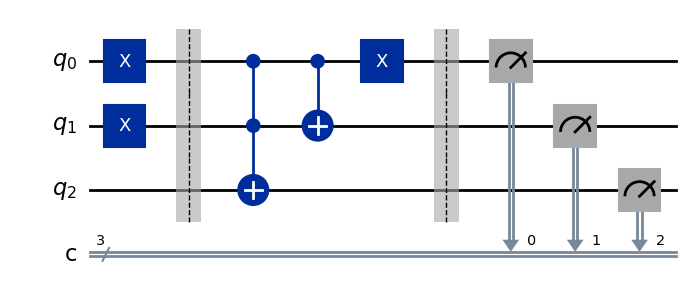

In [3]:
n = int(input("Enter the number of qubits for the increment: "))
# Input binary state
state = input(f"Enter {n}-bit binary value: ")

# Validation
if len(state) != n or any(bit not in '01' for bit in state):
    print("Invalid input!")
    exit()

qc1 = QuantumCircuit(n, n)
# Reverse because Qiskit uses little-endian ordering
for i, bit in enumerate(reversed(state)):
    if bit == '1':
        qc1.x(i)

qc1.barrier()


circuit = increment_circuit(n)
qc1.compose(circuit, inplace=True)
qc1.barrier()
# measurements
qc1.measure(range(n), range(n))

qc1.draw('mpl', filename='increment_circuit.png')


In [4]:
# simulate the circuit
result = sim.run(transpile(qc1, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'100': 1024}
